### import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ast import literal_eval
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("datasets/games_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89341 entries, 0 to 89340
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89341 non-null  int64  
 1   name                      87899 non-null  object 
 2   required_age              89341 non-null  object 
 3   price                     89341 non-null  float64
 4   dlc_count                 89341 non-null  int64  
 5   mac                       89341 non-null  bool   
 6   linux                     89341 non-null  bool   
 7   metacritic_score          89341 non-null  int64  
 8   achievements              89341 non-null  int64  
 9   positive                  89341 non-null  int64  
 10  negative                  89341 non-null  int64  
 11  estimated_owners          89341 non-null  int64  
 12  average_playtime_forever  89341 non-null  int64  
 13  median_playtime_forever   89341 non-null  int64  
 14  discou

Troncate the dataset to show only the games released after 2003, because Steam is officially released in 2003

In [3]:
df = df[df['year'] >= 2003].copy()

### What are the most cited categories?
The *tag* column contains all the categories, i.e., tags that players believe best describe a game. <br>
The *tag* attribute take form of a dictionary of pair (key, count), where key represents a tag, and count represents the number of players believes that tag describes the game. <br> 
The following shows a **wordcloud** of such tags, arranged by the frequencies each tag (!= sum of counts) appeared in the dataset to show which categories of games appear more often according to players<br><br>
The result shows the visual impact of **[singleplayer, indie, action, casual, adventure]** are the most cited tags. This presents a public preference in games genres among the player community 

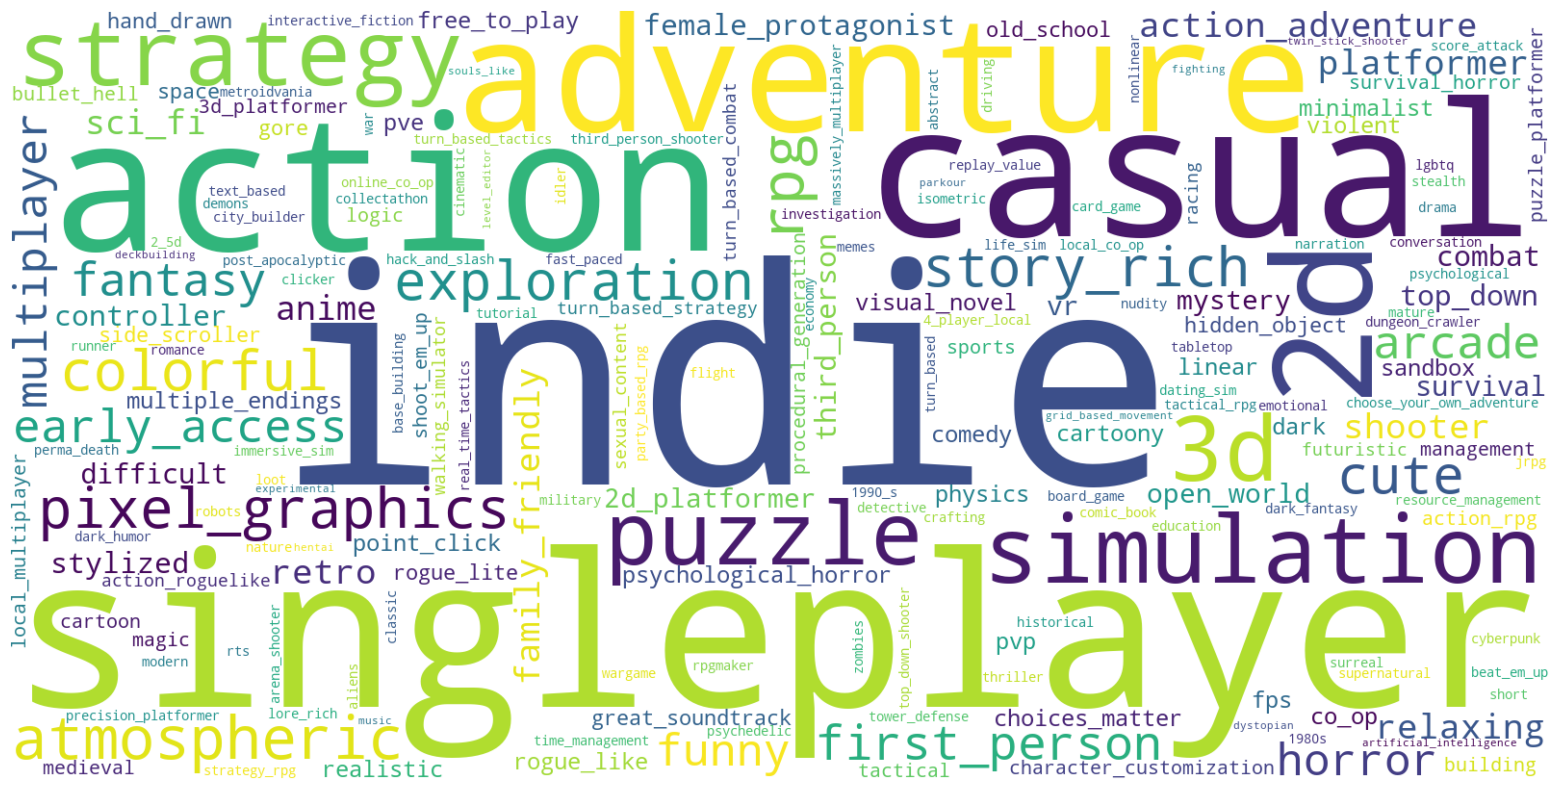

In [4]:
# Count only how often each tag key appears across rows
tag_counter = Counter()

for item in df["tags"]:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

# Wordcloud
wc = WordCloud(width=1600, height=800, background_color="white")
wc.generate_from_frequencies(tag_counter)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

### Game Graveyard
There are a lot of games with 0 *reviews*, 0 *playtime*, and 0 *peak_ccu* present in the dataset. These are the games that no one has ever played. (1 or 2) out of 3  fields have can have 0-value, they could be an error in the dataset, but all three have 0-values is less probabile so. <br>
The area chart shows the trend of number of games published in each year, while highlighting the number of "dead games". Both show an increasing trend over the year.<br><br>

This signals the increasing size of the gaming market, but also tell us that with the releases of new games, more and more competitions fall out of the attention.

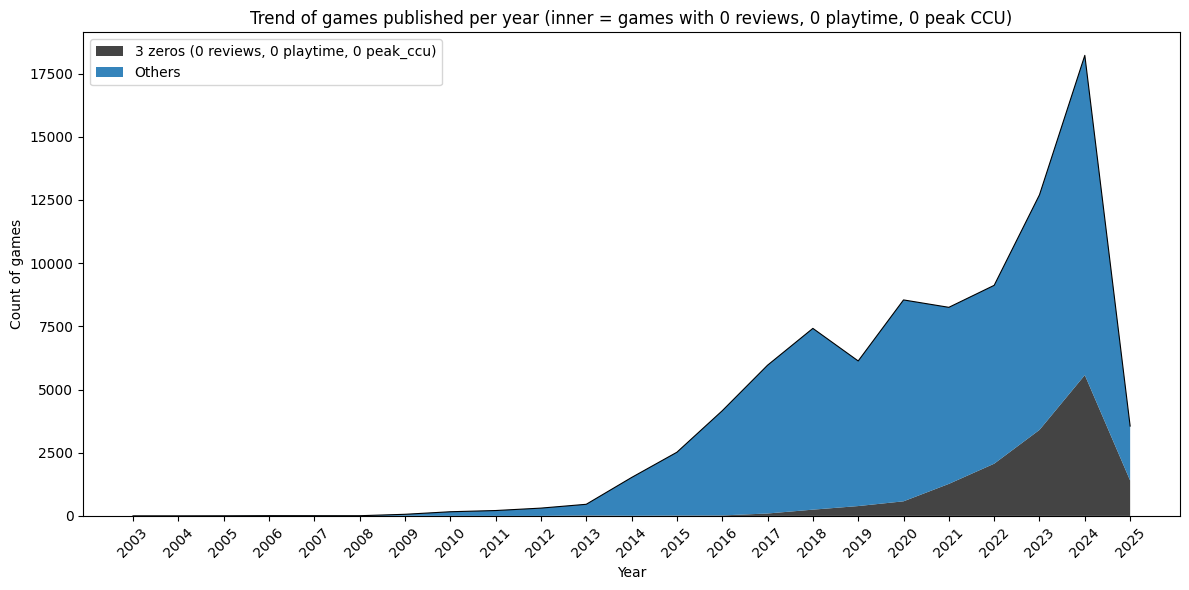

In [5]:
# stacked area: total games per year with inner area = games having 0 reviews, 0 playtime and 0 peak_ccu
total_by_year = df.groupby('year').size().sort_index()
three_zeros = df[(df['num_reviews_total'] == 0) & (df['average_playtime_forever'] == 0) & (df['peak_ccu'] == 0)].copy()
zero_by_year = three_zeros.groupby('year').size().reindex(total_by_year.index, fill_value=0)
others_by_year = total_by_year - zero_by_year

years = total_by_year.index.astype(int)

plt.figure(figsize=(12,6))
plt.stackplot(years,
              zero_by_year.values,
              others_by_year.values,
              labels=['3 zeros (0 reviews, 0 playtime, 0 peak_ccu)', 'Others'],
              colors=['#2f2f2f', '#1f77b4'],
              alpha=0.9)

# outline/top line to emphasize the "others" region
plt.plot(years, zero_by_year.values + others_by_year.values, color='black', lw=0.8)
plt.xlabel('Year')
plt.ylabel('Count of games')
plt.title('Trend of games published per year (inner = games with 0 reviews, 0 playtime, 0 peak CCU)')

# show all year ticks on x-axis
plt.xticks(years, rotation=45)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Price influence
he *hypothesis* behind the dead game is that the **game price** has something to do with a game being "dead", higher the price means bigger the investment.<br><br>
The resulting bar chart that groups the dead games into categories show that the price has little to do with the game popularity, since majority of the dead games are free-to-play or under 5 euros. In theory, these games should attract a large gamer base, thanks to the low economic commitment, but the reality is quite the opposite. 

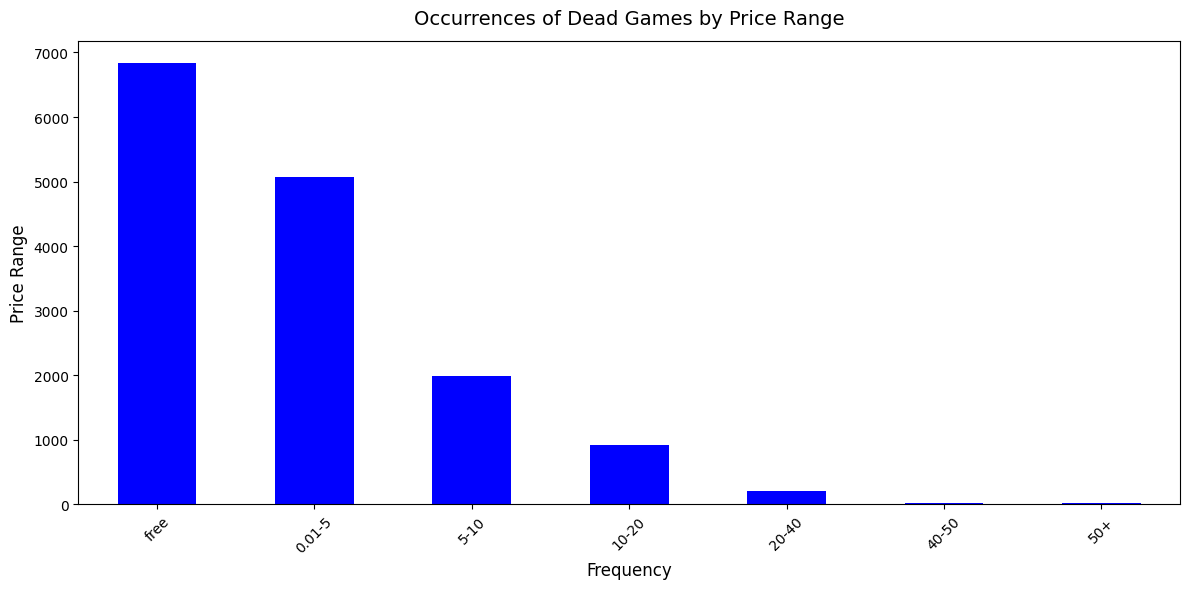

In [6]:
price_zeros = three_zeros['full_price']

# Define bins and labels
bins = [0.0, 0.01, 5, 10, 20, 40, 50, float('inf')]
labels = ['free', '0.01-5', '5-10', '10-20', '20-40', '40-50', '50+']

# Create a series with price values and bin them
price_binned = pd.cut(price_zeros.values, bins=bins, labels=labels, right=False)
price_binned_counts = price_binned.value_counts().sort_index()

ax = price_binned_counts.plot(
    kind='bar',
    figsize=(12, 6),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Price Range', fontsize=12)
ax.set_title('Occurrences of Dead Games by Price Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

#### Game curation, measured by *achievements*
Another hypothesis is that *dead games* are not quality-wise complete, that the **developers did not care for the product**. One subtle indicator is the game's number of achievements or trophys. Throphys are a mechanism to encourage players to engage in the games, rewarding for playing and exploring the game mechanics, a way of showing the dedications the developers put into the games. However, this is not an absolute metric for quality game assessment.<br><br>

The resulting stacked bar chart shows that the hypothesis is not necessarily true, games with lower number of achievements are not by default less cared for, at least not statistically so. 

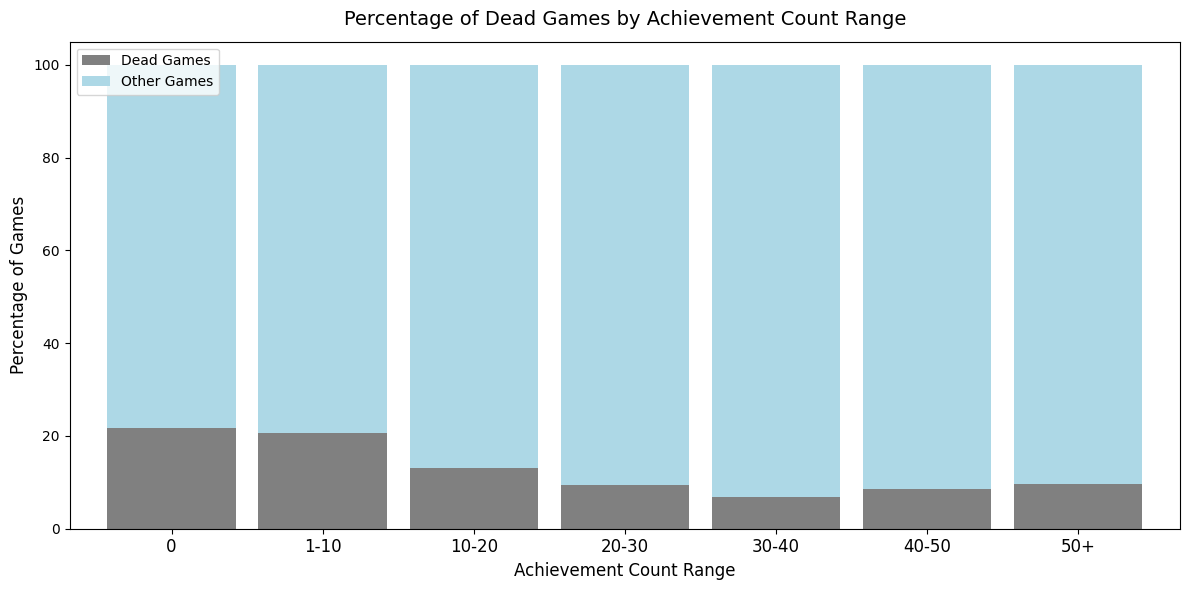

In [7]:
trophy_zeros = three_zeros['achievements']
trophy_all = df['achievements'].copy()

bins = [0, 1, 10, 20, 30, 40, 50, float('inf')]
labels = ['0', '1-10', '10-20', '20-30', '30-40', '40-50', '50+']

trophy_binned_zeros = pd.cut(trophy_zeros.values, bins=bins, labels=labels, right=False)
trophy_binned_all = pd.cut(trophy_all.values, bins=bins, labels=labels, right=False)

trophy_binned_zeros_counts = trophy_binned_zeros.value_counts().sort_index()
trophy_binned_all_counts = trophy_binned_all.value_counts().sort_index()

pct_zeros = (trophy_binned_zeros_counts / trophy_binned_all_counts) * 100
pct_others = 100 - pct_zeros

plot = pd.DataFrame({
    'Dead Games': pct_zeros,
    'Other Games': pct_others
})

ax = plot.plot(
    kind = 'bar',
    stacked = True,
    figsize = (12, 6),
    color = ['grey', 'lightblue'],
    width=0.85
)

ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Achievement Count Range', fontsize=12)
ax.set_ylabel('Percentage of Games', fontsize=12)
ax.set_title('Percentage of Dead Games by Achievement Count Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=0, fontsize=12)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Genre death
Could the **game genres** have anything to do with being "dead"? It is possible that the common player preferences have shifted. So the *new games* of less popular genres get overlooked.<br><br>

However, the horizontal bar chart did not confirm this hypothesis either, by showing the most frequently appeared genres among dead games, we noticed that there aren't any genre stands out, rather the distribution is almost equal among genres.

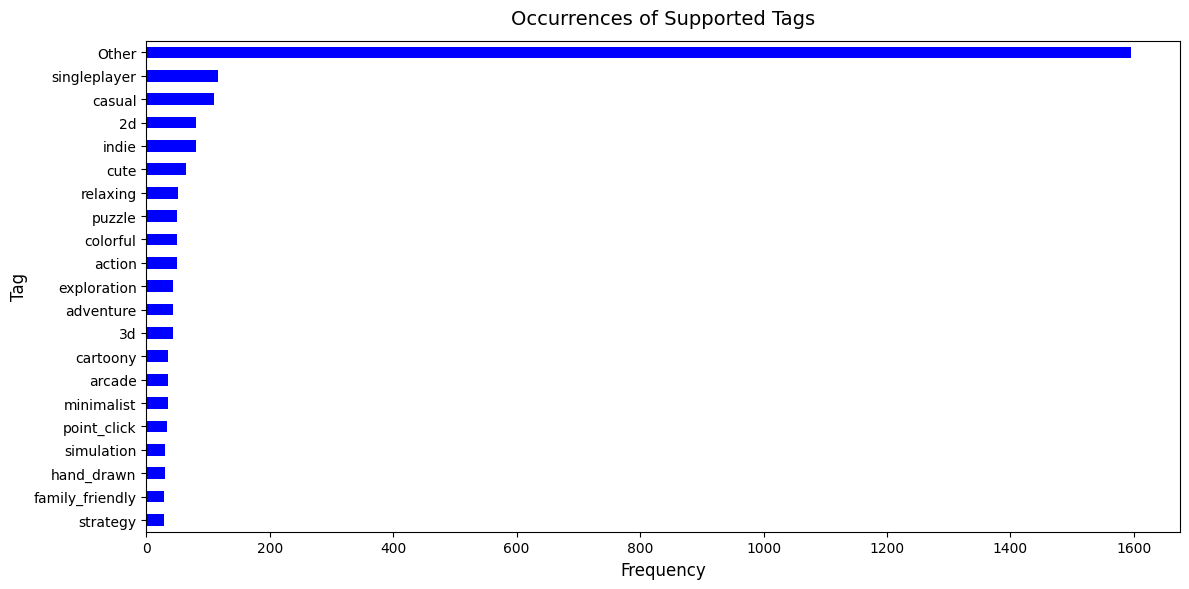

In [8]:
# Count only how often each tag key appears across entries
tag_counter = Counter()

# Filter the 'tags' column, a dictionary on the three_zeros subset
for item in three_zeros['tags']:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

tag_counter = pd.Series(tag_counter).sort_values(ascending=False)

# Limit to top 20 tags + "Other" category
max_bars = 20
if len(tag_counter) > max_bars:
    top = tag_counter.head(max_bars).copy()
    top['Other'] = tag_counter.iloc[max_bars:].sum()
else:
    top = tag_counter.copy()

# Create horizontal bar chart
ax = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Tag', fontsize=12)
ax.set_title('Occurrences of Supported Tags', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

#### Final considearion
From the available data, the reasons behind the continue rise of dead games are inconclusive, it is difficult to statistically prove the trend.<br>
However, a possible explaination could be that most of these games are abbandoned project left unfinished, semi-finised, or testing project. Without a price as a possible indicator, they *scream* low-budget and low-quality with no investors behind the project, they do to encourage players to try them out

### Indie game paradox
How does the ease of publishing low-budget games, so called, indie games changed the gaming market?<br>
The area chart shows that the releases of indie games are steady over the year. But at a first sight, it does not seem to disrupt the gaming market with their presence. It showed a steady increse until 2018 when the number saturated, but, they do still represent a big portion of the market, even in 2024. *Remember, the area chart shows the percentage of the indie games against all other genres combined*.<br><br>

Further analysis are needed to confirm the non-disruption

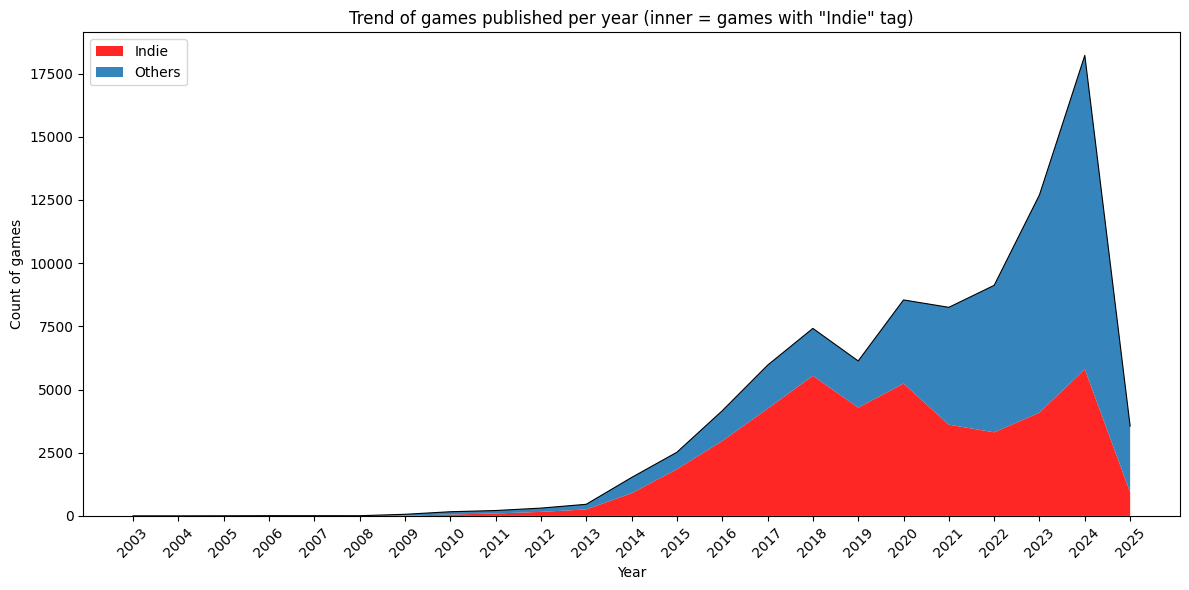

In [9]:
# count games with 'indie' tag per year
def has_indie(t):
    if isinstance(t, str):
        try:
            d = literal_eval(t)
        except Exception:
            return False
    else:
        d = t
    return isinstance(d, dict) and ("indie" in d)


indie_mask = df["tags"].copy().apply(has_indie)
indie_by_year = (
    df[indie_mask].copy().groupby("year").size().reindex(total_by_year.index, fill_value=0)
)
# total_by_year has been defined in the previous cell
others_by_year = total_by_year - indie_by_year

years = total_by_year.index.astype(int)

plt.figure(figsize=(12, 6))
plt.stackplot(
    years,
    indie_by_year.values,
    others_by_year.values,
    labels=["Indie", "Others"],
    colors=["#ff0e0e", "#1f77b4"],
    alpha=0.9,
)

# outline/top line to emphasize the "others" region
plt.plot(years, indie_by_year.values + others_by_year.values, color="black", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Count of games")
plt.title('Trend of games published per year (inner = games with "Indie" tag)')

# show all year ticks on x-axis
plt.xticks(years, rotation=45)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### Indie genres are really overlooked?
Circling back to the 'dead games', we want to know how many of these indie games really ended up in the 'graveyard', because the constant growth of the gaming merket.<br>
The resulting stacked bar chart depicts the size of gaming market by each year while highlighting the portion of the dead/alive indie games.<br><br>

The result shows that the dead indie games occupy a very small portion of the game database, highlighted in color green, however, because the small in number, its portion is barely visible on the graph. Thus, contradicting the hypothesis of indie games being overlooked

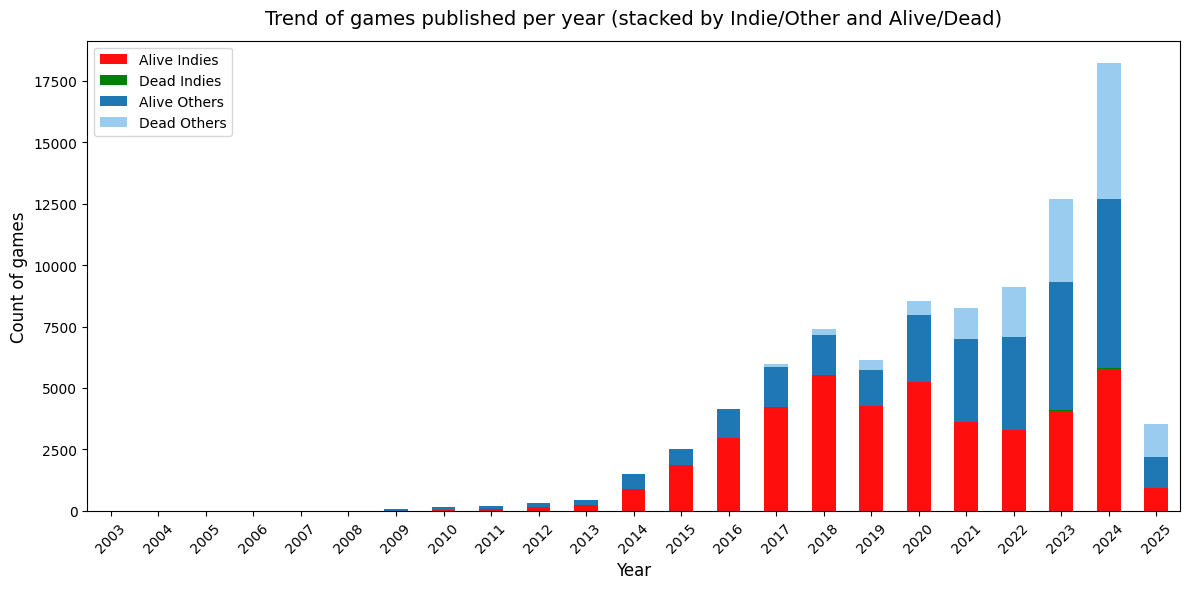

In [10]:
# count dead games with 'indie' tag per year
zero_indie_mask = three_zeros[three_zeros["tags"].apply(has_indie)]
zero_indie_by_year = zero_indie_mask.groupby("year").size().reindex(total_by_year.index, fill_value=0)

alive_indie_by_year = indie_by_year - zero_indie_by_year
zero_others_by_year = zero_by_year - zero_indie_by_year
alive_others_by_year = others_by_year - zero_others_by_year

years = total_by_year.index.astype(int)

plot_indies = pd.DataFrame({
    "Alive Indies": alive_indie_by_year,
    "Dead Indies": zero_indie_by_year,
    "Alive Others": alive_others_by_year,
    "Dead Others": zero_others_by_year,
})

ax = plot_indies.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#ff0e0e", "green", "#1f77b4", "#99ccee"],
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Count of games", fontsize=12)
ax.set_title("Trend of games published per year (stacked by Indie/Other and Alive/Dead)", fontsize=14, pad=12)
ax.set_xticklabels(years, rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### Game attentions
*How does the continuous growth of gaming market size affects the game visibility, and how does the indie genre contributes to it?*<br>
A useful indicator to explore and answer this question is the **median** number of reviews. Reviews represent the number of feedbacks from the players, it can be wither positive or negative, and the steam ensures that an user can leave a review only and only if the user has played the game. Unlike *average_playtime_forever*, whose value is calculated with a certain frequency, *num_reviews_total*'s value is cumulative, and is less likely to have an erronous value when collecting data<br>
The line charts show the yearly trend of median and mean number of reviews of both indie games only and all games. <br><br>

The results show:
1. the attention each game receives gets dilluted with each passing year as shown by the mean reviews of yearly trend of all games
2. majority of games receive very little attention, this is very evident when analyzing the median values, where after 2006, the median reviews of both indie and all-games are so little they seem to reach to zero compared with the 2006's value
3. the comparison between mean and median tells us that only a handful of games receive the most of attention. Take as example the year 2006, where the median value of all games are seemingly zero, but its indie game counter part reaches almost 600000 reviews, and the same year, its mean is ~120000, higher only year with the higher value is 2007.
<br><br>
These findings suggest that either the attention distribution of games is highly skewed, concentrating on only a handlful of game or that for some reason, half the games do not receive the same attention as the other half

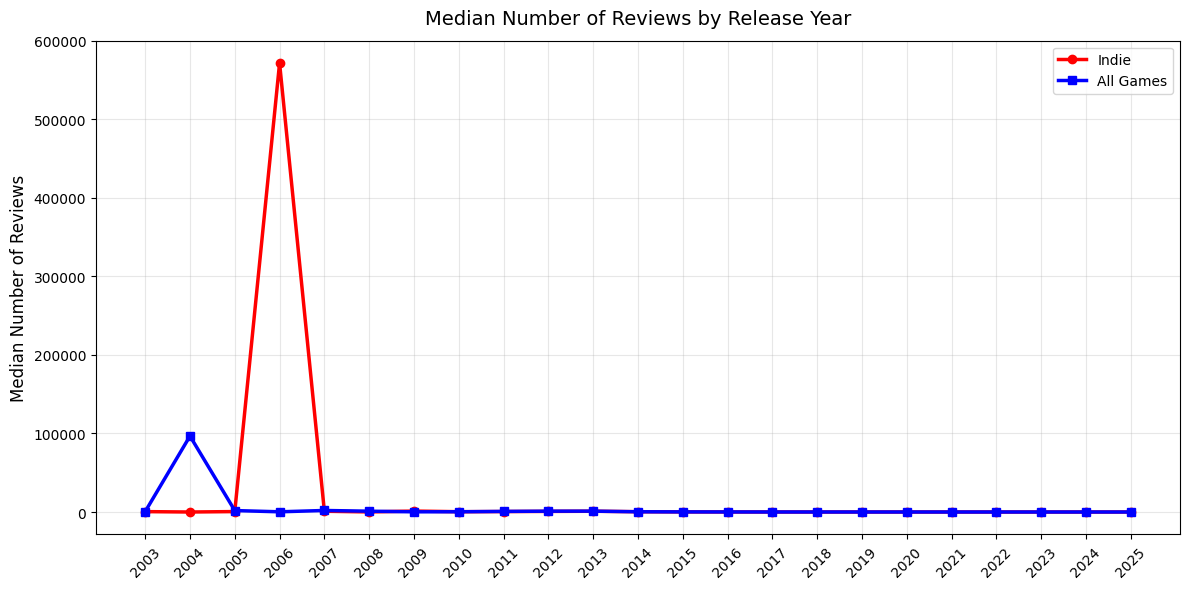

In [11]:
indie_mask = df[df['tags'].copy().apply(has_indie)]
indie_median_by_year = indie_mask.groupby('year')['num_reviews_total'].median().reindex(total_by_year.index, fill_value=0)

all_median_by_year = df.copy().groupby('year')['num_reviews_total'].median().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_median_by_year.index,
    indie_median_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_median_by_year.index,
    all_median_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(total_by_year.index.astype(int))
ax.set_ylabel('Median Number of Reviews', fontsize=12)
ax.set_title('Median Number of Reviews by Release Year', fontsize=14, pad=12)

ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

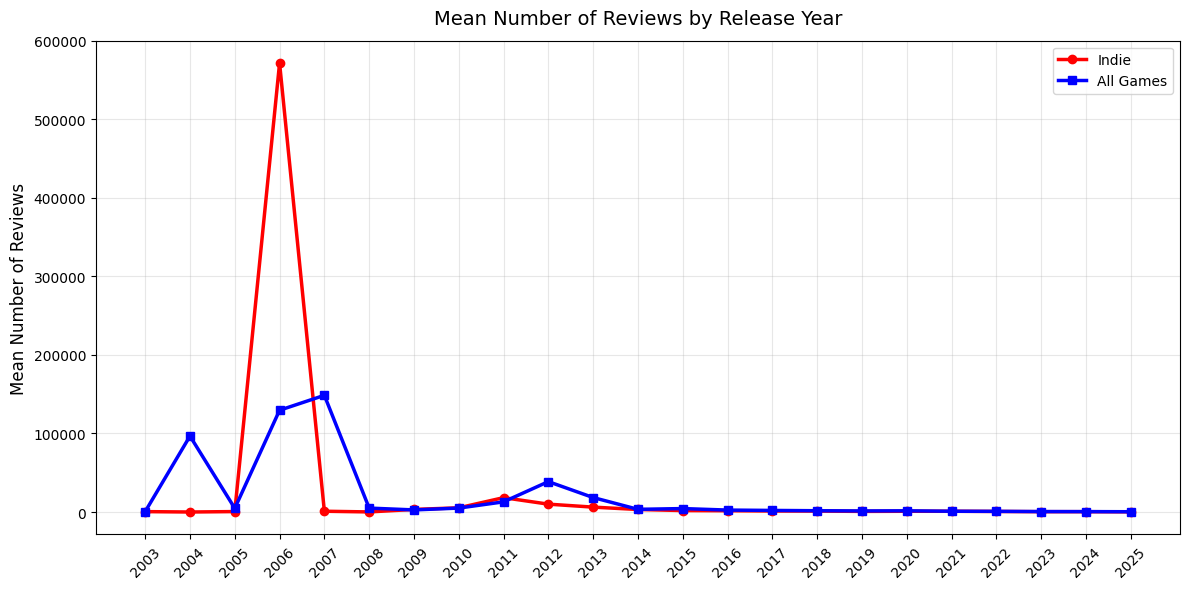

In [12]:
indie_mean_by_year = indie_mask.groupby('year')['num_reviews_total'].mean().reindex(total_by_year.index, fill_value=0)

all_mean_by_year = df.copy().groupby('year')['num_reviews_total'].mean().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_mean_by_year.index,
    indie_mean_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_mean_by_year.index,
    all_mean_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(total_by_year.index.astype(int))
ax.set_ylabel('Mean Number of Reviews', fontsize=12)
ax.set_title('Mean Number of Reviews by Release Year', fontsize=14, pad=12)

ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Case study: 2006
We want to know what makes the 2006 such a particular year in the gaming industry, if it is the boom of the indie genre, or some particular games?<br>
The bar chart shows simply the distribution of num_reviews_total in all the 2006's games<br><br>

The result to the extreme particularity of 2006's value is given by 2 factors:
1. there are only 9 games releases in 2006, 2 of which has tag 'indie'
2. one game, "garry's mode" has an astonishing ~1200000 reviews.
<br><br>

The plots show that 2006 is an exception not because it was a great year for indie genre, but because one blockbuster that influenced the data distribution

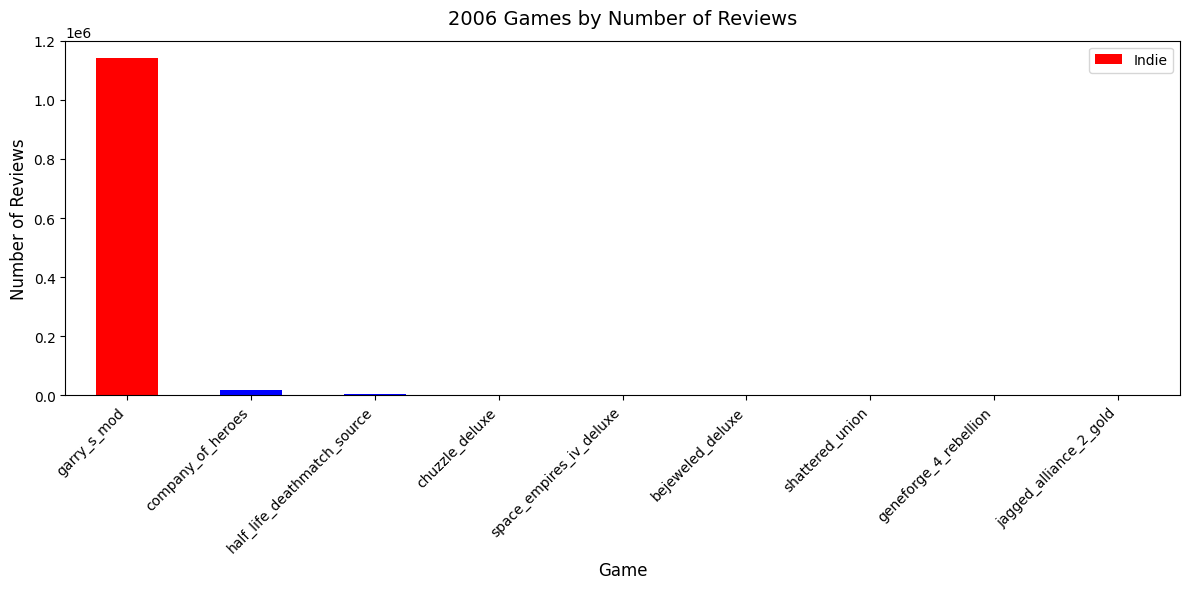

In [13]:
games_2006 = df[df['year'] == 2006].copy()
indie_2006 = games_2006[games_2006['appid'].isin(indie_mask['appid'])]

games_2006 = games_2006.sort_values('num_reviews_total', ascending=False)
ax = games_2006.plot(
    x='name',
    y='num_reviews_total',
    kind='bar',
    figsize=(12, 6),
    color=['red' if appid in indie_2006['appid'].values else 'blue' for appid in games_2006['appid']],
    legend=False
)

ax.set_xlabel('Game', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title(f'2006 Games by Number of Reviews', fontsize=14, pad=12)
ax.set_xticklabels(labels=games_2006['name'], rotation=45, ha='right')
ax.legend(['Indie', 'Other'], loc='upper right')
plt.tight_layout()
plt.show()

#### How much visibility does indie genre have?
We know would like to know if the indie genre really didn't take off in the gaming market, and how much visibility does it really have. We compare the total number of reviews of indie genre against the total number of reviews each year.<br>
The stacked bar chart shows exactly the portion of indie genre visibility against the total

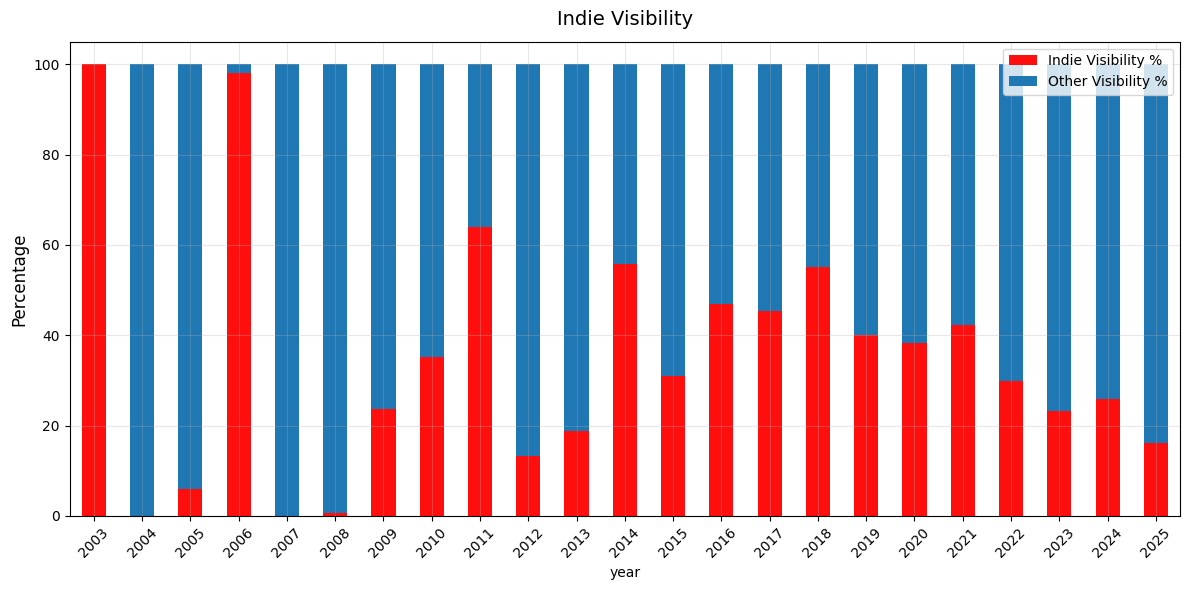

In [15]:
indie_visibility_year = indie_mask.groupby("year")["num_reviews_total"].sum()
indie_visibility_year.loc[2004] = 0 # Add 2004 with 0 visibility to align with total_by_year index
all_visibility_year = df.copy().groupby("year")["num_reviews_total"].sum()

pct_indie_visibility = (indie_visibility_year / all_visibility_year) * 100
pct_other_visibility = 100 - pct_indie_visibility

plot_pct_indie_visibility = pd.DataFrame({
        "Indie Visibility %": pct_indie_visibility,
        "Other Visibility %": pct_other_visibility,
})

ax = plot_pct_indie_visibility.plot(kind="bar", stacked=True, figsize=(12, 6), color=["#ff0e0e", "#1f77b4"])

ax.set_ylabel("Percentage", fontsize=12)
ax.set_title("Indie Visibility", fontsize=14, pad=12)

ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

To analyze the trend of the indie genre, a multi-line plot is traced showing the percentage of new games released in each year(in blue) and the percentage of increase in the indie visibility.<br>
To analyze better the trend, we focus only on the data from 2009 and onward. If 2006 data in included, the plot would be disrupted by the irregularity, the same goes for 2008, which shows a 175 times increase in indie visibility.<br><br>

The result shows that while the indie visibility suffered a steep downfall from 2011 to 2012, it has since maintained a almost smooth change along side the increase in the number of games released each year. 

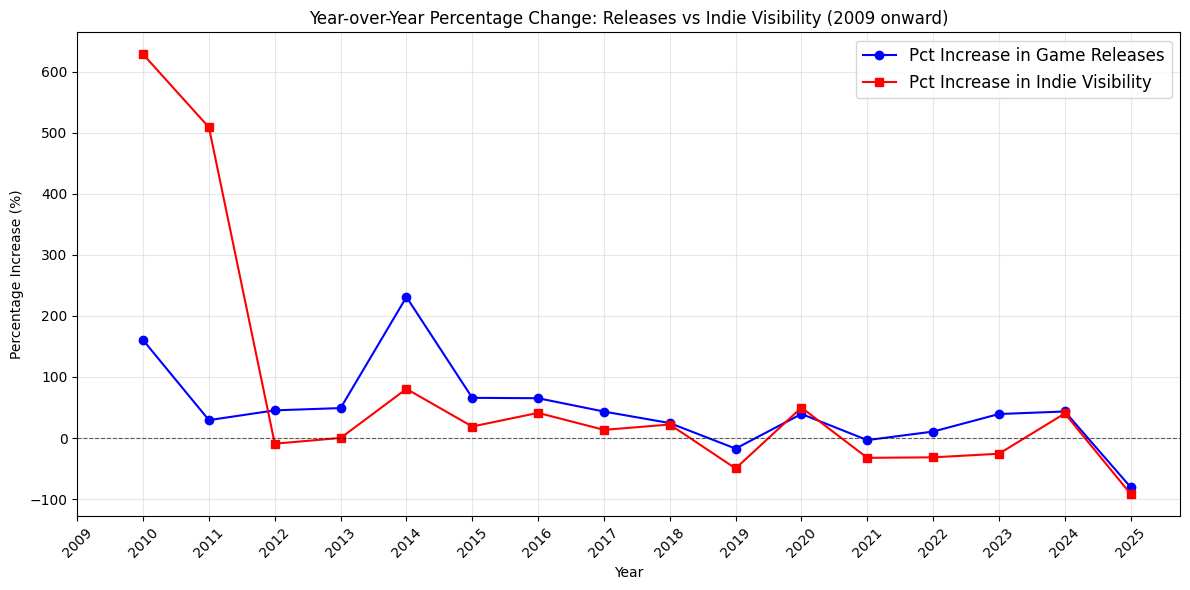

In [16]:
# Align indices from 2009 onward
total = total_by_year.loc[2009:].copy()
indie_vis = indie_visibility_year.reindex(total.index, fill_value=0)

# Year-over-year percent change
total_pct = total.pct_change() * 100
indie_pct = indie_vis.pct_change() * 100

# Remove infinite values (division by zero cases)
total_pct.replace([np.inf, -np.inf], np.nan, inplace=True)
indie_pct.replace([np.inf, -np.inf], np.nan, inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(total_pct.index, total_pct.values, marker='o', color='blue', label='Pct Increase in Game Releases')
ax.plot(indie_pct.index, indie_pct.values, marker='s', color='red', label='Pct Increase in Indie Visibility')

ax.set_xlabel('Year')
ax.set_ylabel('Percentage Increase (%)')
ax.set_title('Year-over-Year Percentage Change: Releases vs Indie Visibility (2009 onward)')
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(total.index, rotation=45)
plt.tight_layout()
plt.show()


#### Final consideration
The indie genre is mainly characterized by the low-budget product, and thus requires lower economic commitment from the user's perspective. Surely the huge success of the 2006' indie game "garry's mod" has set a trend in the industry, followed by other hits like "terraria" or "stardew valley", which are among the most reviewed games of all time. <br>
The genre has seen a steady increase in the number of new games released each year, its visibility has seen drastic changes in the first decade of 2000, but has since secured its place in the vast gaming market, despite the continue increase in the total number of games released each year.<br>

### Winner takes all?
At this point, we observe a subtle fact, that only a few games stands out in the gaming market holding the majority of player's attention. Which is what happened in year 2006.<br>
Hypothesis: *A handful of games hold all the attentions of the players, while the rest receives little to none*.<br>
Lorenz Curve seems to be the most natural visualization tool to show the distribution of 'wealth' among the games and Gini coefficient as a support to show how the 'wealth' is inequally distributed.<br><br>

The resulting graph shows Lorenz curve of *num_reviews_total*, *average_playtime_forever*, and *peak_ccu* , all three attributes can be seen as a measure of wealth in the context of gaming industry, in the absence of sales data.
And they confirm the hypothesis that a small percentage of games hold the most of attentions: 
1. number of reviews is slightly more distributed with risoect of other two attributes.
2. average playtime and ccu's are more concentrated around 10% of games, as the curves show. Around 90% of games share almost 0% (if not precisely zero) wealth. 

In [86]:
# A brief summary on the statistical distribution of the "wealth" features (reviews, playtime, peak CCU)
wealth = df[['num_reviews_total', 'average_playtime_forever', 'peak_ccu']].copy()
for col in wealth.columns:
    print(f"{col}: mean = {wealth[col].mean():.2f}, median = {wealth[col].median():.2f}")

num_reviews_total: mean = 1481.92, median = 13.00
average_playtime_forever: mean = 115.25, median = 0.00
peak_ccu: mean = 1226.84, median = 0.00


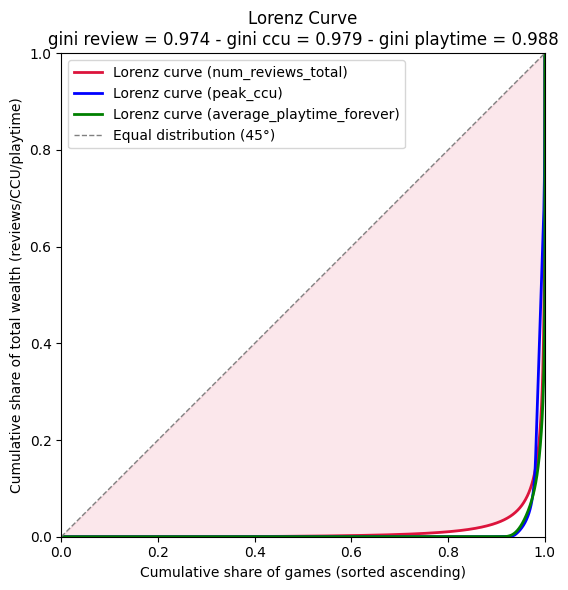

In [30]:
# Lorenz curve and Gini coefficient for 'num_reviews_total' 
# # Gini coefficient: 1 - 2 * area under the Lorenz curve
val_reviews = np.sort(df['num_reviews_total'].values)  # sort values in ascending order
n = len(val_reviews)
cum_vals = np.cumsum(val_reviews)
cum_pct_reviews = cum_vals / cum_vals[-1] # % cumulative of total reviews
cum_pct_games = np.arange(1, n + 1) / n  # % cumulative of games
gini_reviews = 1 - 2 * np.trapezoid(cum_pct_reviews, cum_pct_games)

# Lorenz curves for 'peak_ccu'
val_ccu = np.sort(df['peak_ccu'].values)
cum_val_ccu = np.cumsum(val_ccu)
cum_pct_ccu = cum_val_ccu / cum_val_ccu[-1]
gini_ccu = 1 - 2 * np.trapezoid(cum_pct_ccu, cum_pct_games)

# Lorenz curves for 'average_playtime_forever'
val_playtime = np.sort(df['average_playtime_forever'].values)
cum_val_playtime = np.cumsum(val_playtime)
cum_pct_playtime = cum_val_playtime / cum_val_playtime[-1]
gini_playtime = 1 - 2 * np.trapezoid(cum_pct_playtime, cum_pct_games)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(cum_pct_games, cum_pct_reviews, color='crimson', linewidth=2,
        label='Lorenz curve (num_reviews_total)')

ax.plot(cum_pct_games, cum_pct_ccu, color='blue', linewidth=2,
        label='Lorenz curve (peak_ccu)')

ax.plot(cum_pct_games, cum_pct_playtime, color='green', linewidth=2,
        label='Lorenz curve (average_playtime_forever)')

# Add the 45° line for reference
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Equal distribution (45°)')
ax.fill_between(cum_pct_games, cum_pct_reviews, cum_pct_games,
                 color='crimson', alpha=0.1)

ax.set_xlabel('Cumulative share of games (sorted ascending)')
ax.set_ylabel('Cumulative share of total wealth (reviews/CCU/playtime)')
ax.set_title(f'Lorenz Curve\ngini review = {gini_reviews:.3f} - gini ccu = {gini_ccu:.3f} - gini playtime = {gini_playtime:.3f}')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### Who are these most popular games
We would like to put a name to the label.<br>
The horizontal bar chart shows the top 20 games with the most number of reviews, among them, popular titles like "counter strike 2", "dota 2", "grand theft auto", "terraria", "stardew valley" and more.<br>

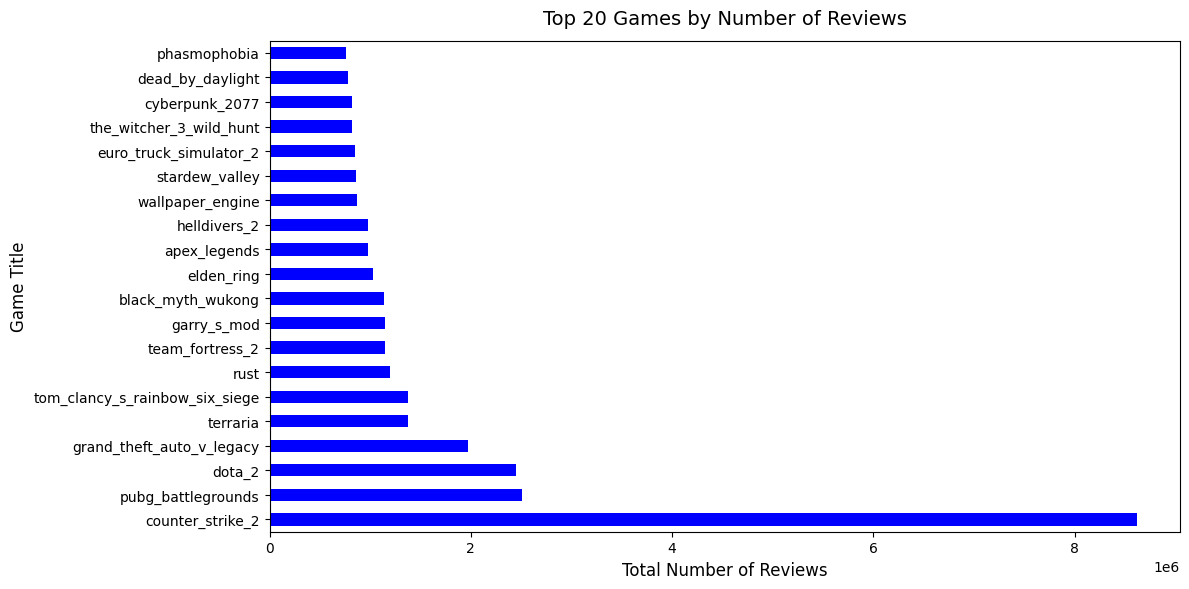

In [41]:
review_rank = df.copy().sort_values('num_reviews_total', ascending=False).reset_index(drop=True)

top = 20

ax = review_rank.head(top).plot(
    x='name',
    y='num_reviews_total',
    kind='barh',
    figsize=(12, 6),
    color='blue',
    legend=False
)
ax.set_xlabel('Total Number of Reviews', fontsize=12)
ax.set_ylabel('Game Title', fontsize=12)
ax.set_title(f'Top {top} Games by Number of Reviews', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

#### Winner keeps it all?
Now we know that the few games controls almost all of the attention in the market, but, is this trend a constant? Because the constant growth in the number of released games, one would naturally think that the attention would be distribution more and more equally among games, higher the denominator, smaller the fraction.<br>
The resulting line chart shows the percentage of attention that the top 1% of games hold in each year, in terms of number of reviews. And a bar chart to remind the growth in the number of games released.<br><br>

Surprisingly, the top 1% of games keep the most of attention each year, after 2015, share of attention are in a steady range of 70-80% if not increasing. This shows that even if the number of competitions grows, the most of player community still prefers a few handful of games.

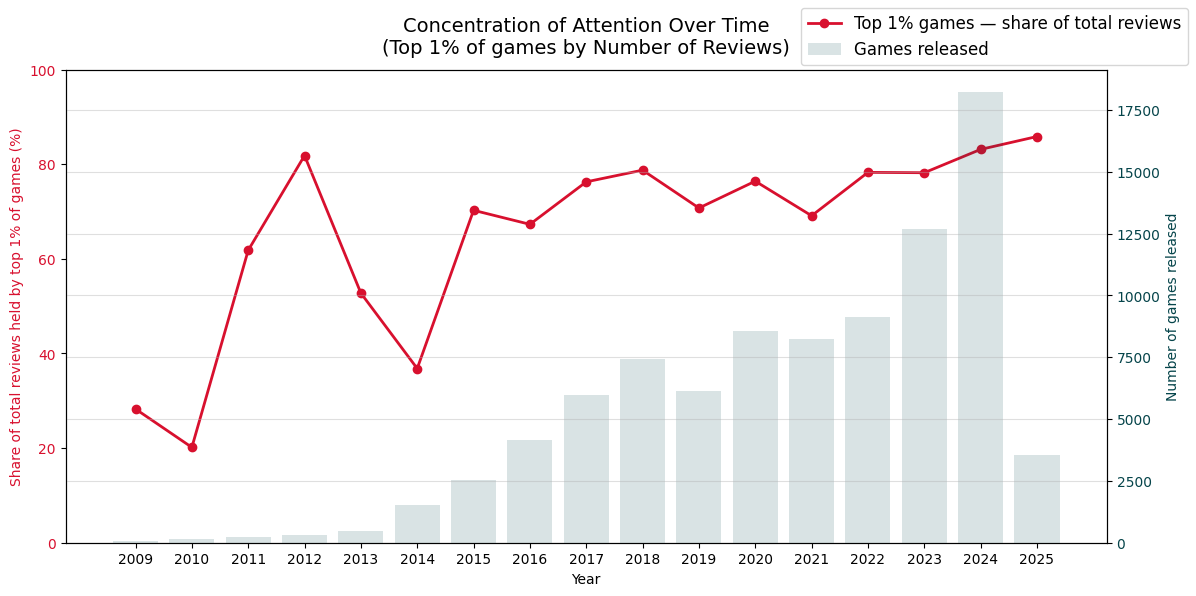

In [87]:
# Compute the share of total reviews held by the top 1% of games for each year
top_pct = 0.01  # top 1%
results = []

for yr in sorted(df['year'].unique()):
    sub = df[df['year'] == yr]['num_reviews_total'].values
    if len(sub) < 20 or sub.sum() == 0:
        continue  # Filter out years with too few games or no reviews

    sub_sorted = np.sort(sub)[::-1] # sort in descending order
    k = max(1, int(len(sub) * top_pct)) # at least 1 game in top 1%
    share = sub_sorted[:k].sum() / sub_sorted.sum() * 100

    results.append({'year': yr, 'n_games': len(sub), 'top1pct_share': share})

concentration_df = pd.DataFrame(results)
years = concentration_df['year'].values

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the top 1% share on the primary y-axis
ax1.plot(concentration_df['year'], concentration_df['top1pct_share'],
         color="#D8102E", marker='o', linewidth=2,
         label='Top 1% games — share of total reviews')
ax1.set_xlabel('Year')
ax1.set_ylabel('Share of total reviews held by top 1% of games (%)', color="#D8102E")
ax1.tick_params(axis='y', labelcolor="#D8102E")
ax1.set_ylim(0, 100)

# Recall the total games released per year on the secondary y-axis
ax2 = ax1.twinx()
ax2.bar(concentration_df['year'], concentration_df['n_games'],
        alpha=0.15, color="#05444A", label='Games released')
ax2.set_ylabel('Number of games released', color="#05444A")
ax2.tick_params(axis='y', labelcolor="#05444A")

ax1.set_title('Concentration of Attention Over Time\n(Top 1% of games by Number of Reviews)', fontsize=14, pad=12)
fig.legend(loc='upper right', fontsize=12)

plt.grid(alpha=0.4)
plt.xticks(years, rotation=0)
plt.tight_layout()
plt.show()

#### Final consideration
A few games stand out in the constant growth of the gaming market, holding the majority of the 'wealth' leaving the others a more scarse visibility. From the number of reviews point of view, it means, at least that many people has ever played that game, confirming the high skewness of the industry's attention distribution. 